In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import sys
sys.path.append("..")
#from dpa.dpa_fit import DPA
import dpa.dpa_fit as fit
import importlib

In [2]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# First, transpose to (time, lat, lon) if needed
def data_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

def predictors_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [4]:
# load my temperature data
# Load your NetCDF file
#ds_train = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_le.nc")
#ds_test = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_eth_test.nc")
#ds_train


In [4]:
ds = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/Europe_subset_TREFHT_CESM2_LE_5daily_JJA/stacked_TREFHT_JJA.nc")
ds

ds_train = ds.isel(time=slice(0, 4769 * 80))
ds_test = ds.isel(time=slice(4769 * 80, 476900))

x_tr = data_to_torch(ds_train, "TREFHT")
x_te = data_to_torch(ds_test, "TREFHT")

torch.Size([381520, 1024])
torch.Size([95380, 1024])


In [5]:
ds_z500 = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/PC_time_series_Z500_5daily_JJA/pseudoPCs_EOFs_Z500_5daily_100ensmembers_JJA_not_scaled.nc")
ds_z500

z500 = predictors_to_torch(ds_z500, "pseudo_pcs")
z500

z500_train = z500[:381520,:]
z500_train.shape

torch.Size([476900, 1000])


torch.Size([381520, 1000])

In [8]:
z500_test = z500[381520:,:]#.to(device)
z500_test.shape

torch.Size([95380, 1000])

In [5]:
#x_tr = data_to_torch(ds_train)
#x_te = data_to_torch(ds_test)

#slp_tr = predictors_to_torch(ds_train)
#slp_te = predictors_to_torch(ds_test)

torch.Size([301200, 1024])
torch.Size([36144, 1024])
torch.Size([301200, 1001])


In [6]:
importlib.reload(fit)
dpa = fit.DPA(data_dim=1024, latent_dims=[10], num_layer=6, hidden_dim=100, device=device, joint = True)

GPU is available, running on GPU.



In [ ]:
importlib.reload(fit)
dpa.train(x_tr, 
          z500_train, 
          #x_te,
          #z500_test,
          batch_size=500, 
          num_epochs=100, 
          save_model_every=500,
          print_every_nepoch=1, 
          save_dir="saved_models_17062025_2/", 
          save_loss=True, 
          print_all_k = True)

Start training with 764 batches each of size 500.

[Epoch 1], 21.9820
 pred 	51.3647
 var 	58.7653
 Ldl 	45496.6687

Training linear model ...
[Epoch 2], 20.8578
 pred 	51.7873
 var 	61.8589
 Ldl 	44648.6207

Training linear model ...
[Epoch 3], 20.5396
 pred 	51.7479
 var 	62.4166
 Ldl 	44058.5201

Training linear model ...
[Epoch 4], 19.6463
 pred 	50.0539
 var 	60.8153
 Ldl 	43469.6466

Training linear model ...
[Epoch 5], 18.6445
 pred 	47.0188
 var 	56.7485
 Ldl 	42514.5547

Training linear model ...
[Epoch 6], 17.8080
 pred 	43.0207
 var 	50.4253
 Ldl 	42111.4437

Training linear model ...
[Epoch 7], 17.1504
 pred 	39.8933
 var 	45.4856
 Ldl 	42293.8188

Training linear model ...
[Epoch 8], 16.7358
 pred 	37.8886
 var 	42.3057
 Ldl 	42257.6441

Training linear model ...
[Epoch 9], 16.4393
 pred 	36.5721
 var 	40.2658
 Ldl 	42281.0800

Training linear model ...
[Epoch 10], 16.2337
 pred 	35.6919
 var 	38.9164
 Ldl 	42288.1695

Training linear model ...
[Epoch 11], 16.1106
 pred 	3

In [42]:
torch.save(dpa.model.state_dict(), "saved_models_17062025_1/epoch_100.pt")

In [18]:
z500_test.device

device(type='cuda', index=0)

In [19]:
x_pred = dpa.model.predict(z500_test, double=True)#.cpu()

In [33]:
print(len(x_pred))
x_pred[0].shape

4


torch.Size([95380, 10])

In [34]:
def torch_to_dataarray(x_tensor, coords_ds, lat_dim=32, lon_dim=32, name="variable"):
    """
    Convert a flattened 2D torch tensor to a 3D xarray.DataArray (lat, lon, time).

    Parameters:
    ----------
    x_tensor : torch.Tensor
        A 2D tensor of shape (time_steps, lat_dim * lon_dim), or a 1D tensor to be reshaped.
    lat_dim : int
        Number of latitude points.
    lon_dim : int
        Number of longitude points.
    coords_ds : xarray.Dataset
        Dataset containing 'lat', 'lon', and 'time' coordinates to assign.
    name : str, optional
        Name of the variable in the DataArray.

    Returns:
    -------
    xarray.DataArray
        The reshaped and labeled data as an xarray.DataArray.
    """
    # Step 1: Convert to NumPy
    data_np = x_tensor.detach().cpu().numpy()

    # Step 2: Determine time_steps and reshape
    time_steps = data_np.shape[0]
    data_np = data_np.reshape(time_steps, lat_dim, lon_dim)

    # Step 3: Transpose to (lat, lon, time)
    data_np = data_np.transpose(1, 2, 0)

    # Step 4: Create the DataArray
    da = xr.DataArray(
        data_np,
        dims=("lat", "lon", "time"),
        coords={
            "lat": coords_ds.lat,
            "lon": coords_ds.lon,
            "time": coords_ds.time
        },
        name=name
    )

    return da

In [37]:
reconstructed_da_1 = torch_to_dataarray(x_pred[0], coords_ds=ds_test, name="Temperature")
reconstructed_da_2 = torch_to_dataarray(x_pred[1], coords_ds=ds_test, name="Temperature")

In [38]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_temperature_panel(ax, dataarray, vmax_shared, sample_nr=None, title=""):
    """
    Plot a single temperature panel on a given axis with Cartopy.

    Parameters:
    ----------
    ax : matplotlib.axes._subplots.AxesSubplot
        Axis on which to plot.
    dataarray : xarray.DataArray
        The temperature data to plot.
    title : str
        Title for the subplot.
    vmax_shared : float
        Symmetric max value for colormap scaling (vmin = -vmax).
    """
    levels = np.linspace(-5, 5, 11)

    p = dataarray.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=-vmax_shared,
        vmax=vmax_shared,
        levels=levels,
        add_colorbar=False
    )
    ax.set_title(title)
    ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    #ax.gridlines(draw_labels=False)
    if sample_nr is not None:
        ax.text(
            x=0, y=0.5,                # left edge, center vertically
            s=sample_nr,          # your annotation text
            transform=ax.transAxes,   # interpret x/y in axis coordinates (0–1)
            rotation=90,              # rotate to align with y-axis
            va='center', ha='right',  # vertical/horizontal alignment
            fontsize=12
        )
    return p


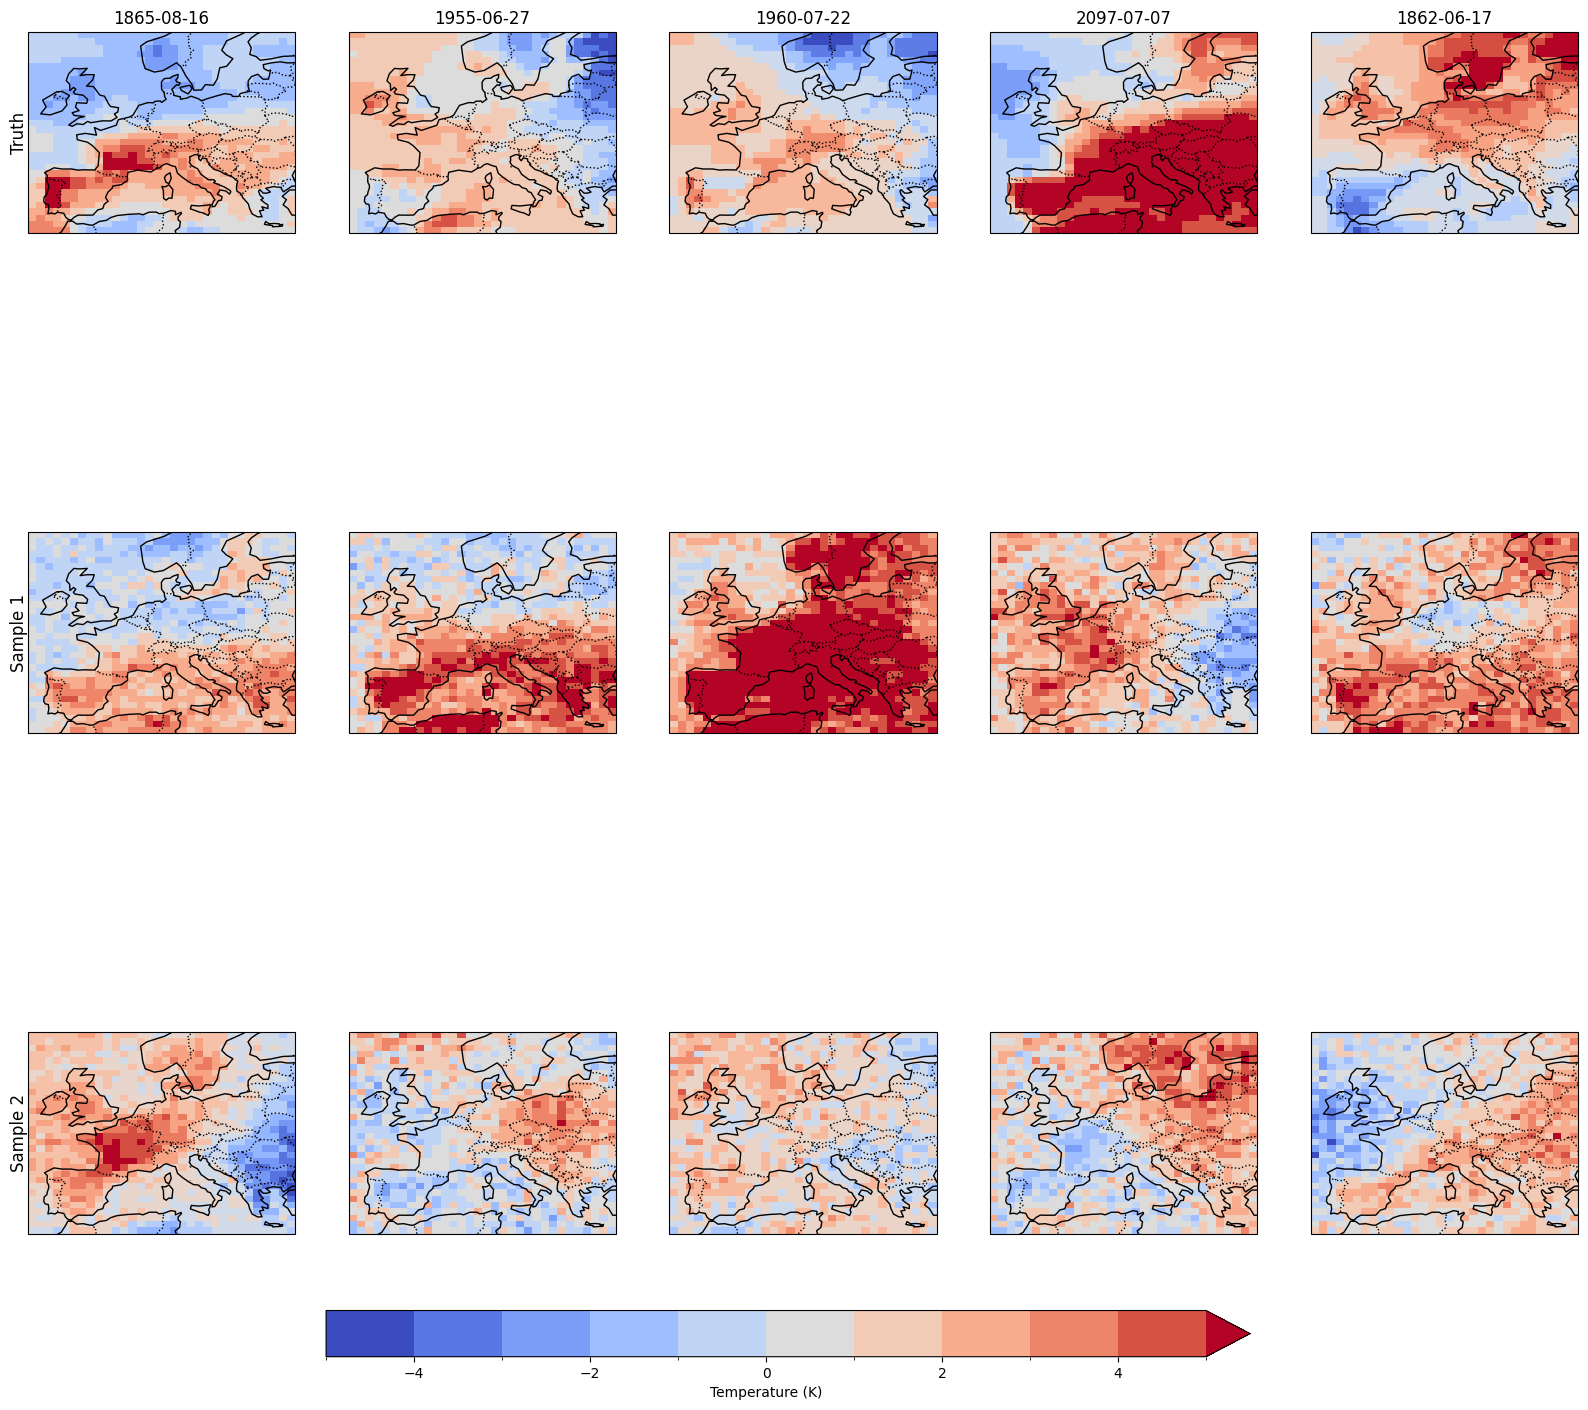

In [40]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
list_of_dataarrays_re = [reconstructed_da_1, reconstructed_da_2]
timesteps=[300,2000,2100,4700,5000]
for i, (ax, t) in enumerate(zip(axs, timesteps)):
    title = f"{str(ds_test.isel(time=t).time.values)[:10]}"
    if i ==0:
        plot_temperature_panel(ax, ds_test.TREFHT.isel(time=t), title = title, vmax_shared=5, sample_nr = "Truth")
        plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5, sample_nr = "Sample 1")
        plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5, sample_nr = "Sample 2")
        
    else:
        plot_temperature_panel(ax, ds_test.TREFHT.isel(time=t), title = title, vmax_shared=5)
        plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5)
        




# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

#plt.tight_layout()
#plt.savefig("dpa_samples.pdf", format='pdf')
plt.show()

In [21]:
# Create the DataArray
reconstructed_da = xr.DataArray(
    data_np_reverted,
    dims=("lat", "lon", "time"),
    coords={
        "lat": ds_test.lat,
        "lon": ds_test.lon,
        "time": ds_test.time
    },
    name="Temperature"  # You can name the variable
)

reconstructed_da

<xarray.DataArray 'Temperature' (lat: 32, lon: 32, time: 36144)> Size: 148MB
array([[[-2.9796371e-01,  2.3134832e-01,  9.3954444e-01, ...,
          2.2086205e+00,  1.7993803e+00,  2.5778930e+00],
        [-1.2366258e-01,  2.7258059e-01,  6.0542625e-01, ...,
          2.3825934e+00,  1.5460601e+00,  2.9645648e+00],
        [-2.9793161e-01,  1.7594829e-01,  6.9704992e-01, ...,
          2.5138679e+00,  1.9327257e+00,  3.3636615e+00],
        ...,
        [ 1.9111743e+00,  6.8237692e-02,  1.5439664e+00, ...,
          1.1379571e+00,  2.9865987e+00,  3.2573462e+00],
        [ 1.7360735e+00, -7.7470100e-01,  1.1328558e+00, ...,
          1.6573213e+00,  3.4861479e+00,  3.1835520e+00],
        [ 1.8413501e+00, -3.3057466e-01,  1.1513271e+00, ...,
          1.5932688e+00,  3.5784740e+00,  3.7531297e+00]],

       [[-6.5681338e-04,  1.5239987e-01,  8.0314523e-01, ...,
          2.3681312e+00,  1.4508010e+00,  1.8810844e+00],
        [ 2.6455542e-01,  3.4988084e-01,  7.3072249e-01, ...,
          2.7362146e+00,  1.9028456e+00,  2.7859144e+00],
        [-1.3427211e-01,  7.6009661e-02,  5.4402125e-01, ...,
          2.4989204e+00,  2.0825722e+00,  2.6841505e+00],
...
          4.7883372e+00,  2.9399242e+00,  4.7928295e+00],
        [ 6.1106014e+00,  5.5183377e+00, -2.3380127e+00, ...,
          5.0420365e+00,  3.2298422e+00,  5.3353548e+00],
        [ 6.4329052e+00,  5.4004421e+00, -2.5182822e+00, ...,
          4.7914743e+00,  3.5946114e+00,  5.3771558e+00]],

       [[-1.2909266e+00,  9.2631221e-01,  2.3872858e-01, ...,
         -1.7440796e+00, -5.5848241e-01,  8.8377833e-01],
        [-1.0652452e+00,  3.9219415e-01,  3.1097227e-01, ...,
         -1.8725858e+00, -1.8853765e+00,  1.5011338e+00],
        [-8.2807392e-01,  7.3648071e-01,  7.7208400e-01, ...,
         -1.7190380e+00, -1.5042104e+00,  1.8766499e+00],
        ...,
        [ 6.0164208e+00,  5.8019452e+00, -2.7019629e+00, ...,
          5.1066604e+00,  3.3067508e+00,  4.7165818e+00],
        [ 6.1231022e+00,  6.2131476e+00, -2.8273778e+00, ...,
          4.6846542e+00,  4.2560363e+00,  5.1331472e+00],
        [ 5.9429913e+00,  5.7900553e+00, -2.5433300e+00, ...,
          4.6613779e+00,  3.4371419e+00,  5.5002828e+00]]],
      shape=(32, 32, 36144), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00:00:00

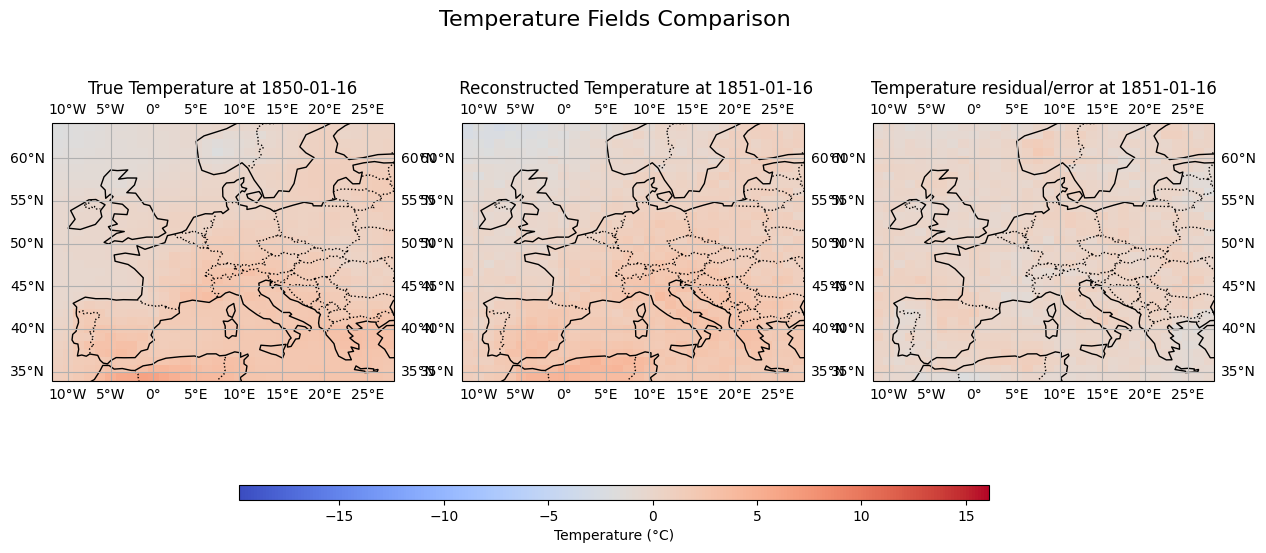

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[ 0.02012706,  0.51995242,  0.36368382, ...,  0.64705133,
         0.56891847,  0.41172445],
       [-0.41864586, -0.44340324,  0.24845767, ...,  0.88952732,
         0.48092794,  0.64109445],
       [-0.18926752,  0.2972821 ,  0.72947037, ...,  0.98633838,
         0.65580428,  0.14359713],
       ...,
       [-0.00955749,  0.19443536,  0.68611813, ..., -0.5264554 ,
        -0.21508348, -0.41334581],
       [ 0.69813633,  0.38584328,  0.6501646 , ..., -0.60575438,
         0.22800958, -0.29517347],
       [ 0.9238925 ,  0.17176306,  0.69945812, ..., -0.09191573,
         0.05644792, -0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [48]:
# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Example: Load data (you should already have your `reconstructed_da`)
# reconstructed_da = xr.open_dataset('your_file.nc')['Temperature']

# Prepare figure with 2 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()


# Set common color limits across both plots
vmin = reconstructed_da.min().item()
vmax = reconstructed_da.max().item()

# Plot on first panel
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important! No individual colorbars
)
axs[0].set_title(f"True Temperature at {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

#####################################################################
# Plot on second panel
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[1].set_title(f" Reconstructed Temperature at {str(time2.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

#####################################################################
# Plot on third panel
p3 = (reconstruction_to_plot - test_truth_to_plot).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[2].set_title(f"Temperature residual/error at {str(time2.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# ===========================
# Here's the important fix:
# Create a new axes for the colorbar
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.03])  
# [left, bottom, width, height] in figure coordinates (0 to 1)

cbar = fig.colorbar(p2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature (°C)')
# ===========================

# Add an overall figure title
fig.suptitle('Temperature Fields Comparison', fontsize=16)

#plt.tight_layout()
plt.show()

test_truth_to_plot - reconstruction_to_plot

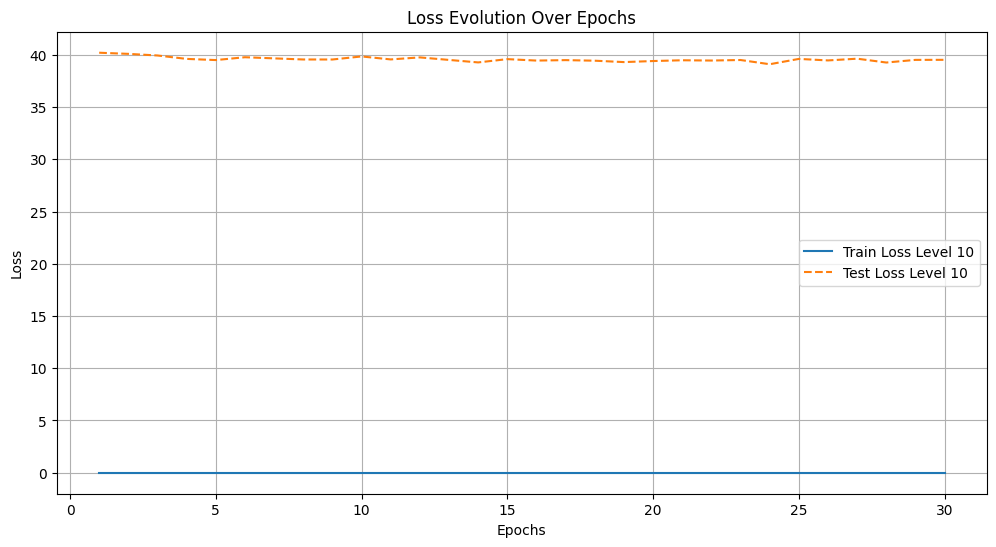

In [8]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    """
    Parse the .log file to extract training and testing losses.

    Args:
        log_file_path (str): Path to the .log file.

    Returns:
        dict: A dictionary containing train and test losses over epochs.
    """
    train_losses = []
    test_losses = []
    with open(log_file_path, 'r') as file:
        for line in file:
            # Match train loss lines
            train_match = re.match(r"\[Epoch \d+\] (.+)", line)
            if train_match:
                train_losses.append([float(x.strip()) for x in train_match.group(1).split(",")])

            # Match test loss lines
            test_match = re.match(r"\(test\)\s+(.+)", line)
            if test_match:
                test_losses.append([float(x.strip()) for x in test_match.group(1).split(",")])

    return {
        "train": np.array(train_losses),
        "test": np.array(test_losses),
    }

def plot_loss_evolution(loss_data, k_levels=None, save_path=None):
    """
    Plot the loss evolution over epochs for selected `k` levels during training and testing.

    Args:
        loss_data (dict): A dictionary containing train and test losses over epochs.
        k_levels (list, optional): List of `k` levels to plot. Defaults to all available levels.
        save_path (str, optional): Path to save the plot. If None, the plot is displayed.
    """
    train_losses = loss_data['train']
    test_losses = loss_data['test']

    if k_levels is None:
        k_levels = range(train_losses.shape[1])  # Default to all levels

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))
    for k in k_levels:
        if k < train_losses.shape[1]:  # Ensure k is valid
            plt.plot(epochs, train_losses[:, k], label=f"Train Loss Level {k}")
            if len(test_losses) > 0:
                plt.plot(epochs, test_losses[:, k], '--', label=f"Test Loss Level {k}")
        else:
            print(f"Warning: k level {k} is out of bounds and will be ignored.")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Evolution Over Epochs")
    plt.legend()
    plt.grid()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()

# Example usage
log_file_path = "saved_models/log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)

# Specify the `k` levels you want to plot, or set to `None` to plot all levels
k_levels_to_plot = [10]  # Example: Plot only levels 0 and 2
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

In [ ]:
total_residual = reconstructed_da - ds_test
total_residual

/tmp/ipykernel_3350826/2335559975.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbars


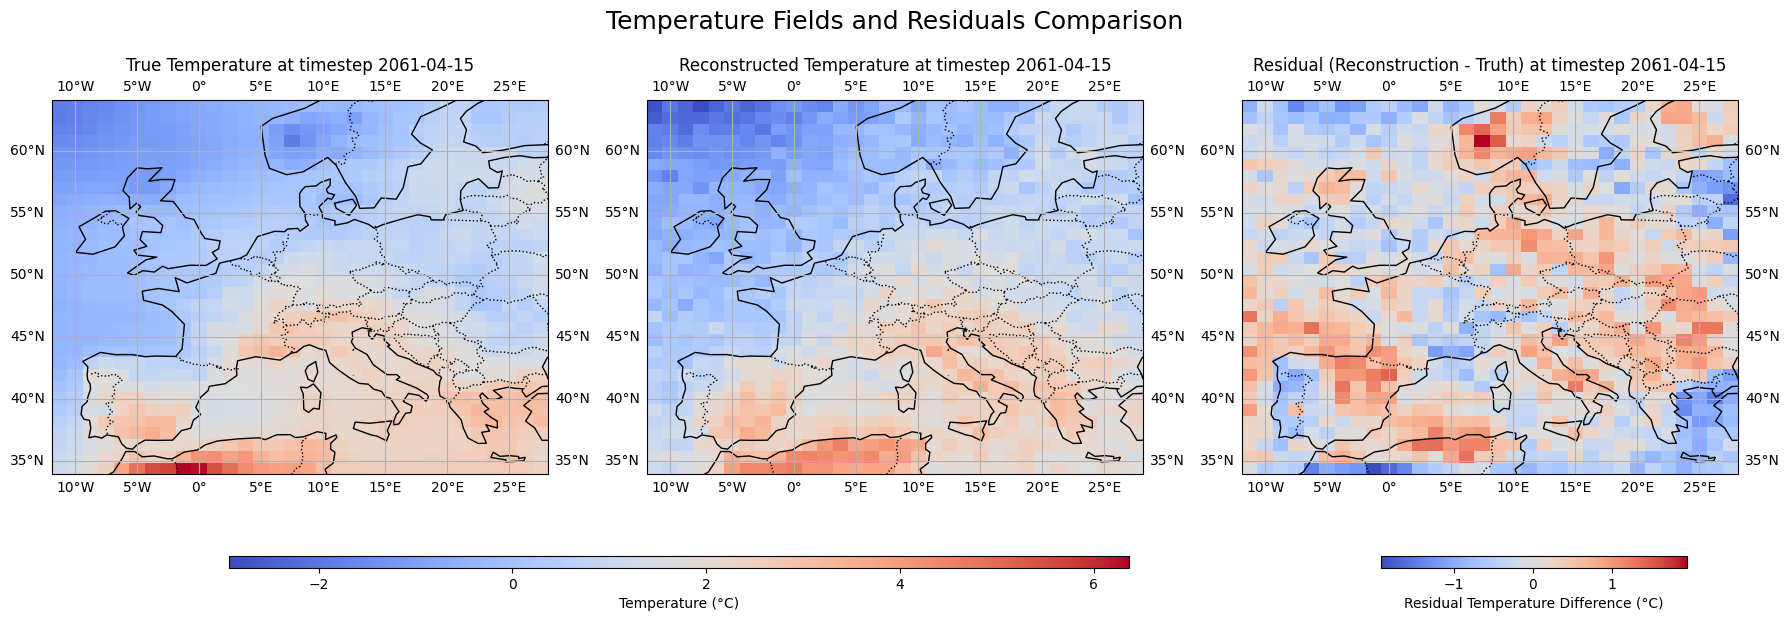

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[-0.02012706, -0.51995242, -0.36368382, ..., -0.64705133,
        -0.56891847, -0.41172445],
       [ 0.41864586,  0.44340324, -0.24845767, ..., -0.88952732,
        -0.48092794, -0.64109445],
       [ 0.18926752, -0.2972821 , -0.72947037, ..., -0.98633838,
        -0.65580428, -0.14359713],
       ...,
       [ 0.00955749, -0.19443536, -0.68611813, ...,  0.5264554 ,
         0.21508348,  0.41334581],
       [-0.69813633, -0.38584328, -0.6501646 , ...,  0.60575438,
        -0.22800958,  0.29517347],
       [-0.9238925 , -0.17176306, -0.69945812, ...,  0.09191573,
        -0.05644792,  0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)
time1 = reconstruction_to_plot.time

# Prepare figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()

# Set shared color limits for the first two panels
vmin_shared = min(test_truth_to_plot.min().item(), reconstruction_to_plot.min().item())
vmax_shared = max(test_truth_to_plot.max().item(), reconstruction_to_plot.max().item())

# Set separate color limits for the residual
residual = reconstruction_to_plot - test_truth_to_plot
vmin_residual = residual.min().item()
vmax_residual = residual.max().item()

# --- Plot first panel: True Temperature ---
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_shared,
    vmax=vmax_shared,
    add_colorbar=False
)
axs[0].set_title(f"True Temperature at timestep {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

# --- Plot second panel: Reconstructed Temperature ---
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_shared,
    vmax=vmax_shared,
    add_colorbar=False
)
axs[1].set_title(f"Reconstructed Temperature at timestep {str(time1.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

# --- Plot third panel: Residual/Error ---
p3 = residual.plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin_residual,
    vmax=vmax_residual,
    add_colorbar=False
)
axs[2].set_title(f"Residual (Reconstruction - Truth) at timestep {str(time1.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# =======================
# Create shared colorbar for the first two panels
cbar_ax_shared = fig.add_axes([0.13, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
cbar_shared = fig.colorbar(p1, cax=cbar_ax_shared, orientation='horizontal')
cbar_shared.set_label('Temperature (°C)')

# Create separate colorbar for residual
cbar_ax_residual = fig.add_axes([0.77, 0.05, 0.17, 0.02])  # [left, bottom, width, height]
cbar_residual = fig.colorbar(p3, cax=cbar_ax_residual, orientation='horizontal')
cbar_residual.set_label('Residual Temperature Difference (°C)')
# =======================

# Add overall figure title
fig.suptitle('Temperature Fields and Residuals Comparison', fontsize=18)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbars
plt.show()

# (Optional) if you want to immediately see the numerical residual
residual
